# VP-SDE DDPM++ on Oxford Flowers with Augmentation

Train and evaluate a VP-SDE score model with a DDPM++/NCSN++ backbone on augmented Oxford Flowers images.


In [ ]:
RUN_TRAINING = True
RUN_EVALUATION_AFTER_TRAINING = True

LOAD_FROM_CHECKPOINT = False
CHECKPOINT_TO_LOAD = "/content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_augmented_ddpmpp_1760_epochs.pth"

SAVE_CHECKPOINTS = True

target_class_name = "flowers"
batch_size=128

# Training
epochs=1760
learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.995

# VP-SDE beta schedule
bar_b_min = 0.1
bar_b_max = 20.0

# Sampling
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 0

# Evaluation
fid_num_generated = 1000
fid_gen_batch_size = 64
mem_num_generated = 64
mem_reference_images = 5000

# Paths
path = "/content/drive/MyDrive/DD2424/Project/working_nets"


## Imports


In [ ]:
import os
import sys
import math
import time
import copy
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Subset, DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm


device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Google Drive


In [ ]:
from google.colab import drive

drive.mount("/content/drive")
os.makedirs(path, exist_ok=True)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

print("Project path:", path)
print("Files in project path:", os.listdir(path))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project path: /content/drive/MyDrive/DD2424/Project/working_nets
Files in project path: ['score_sde_pytorch', 'Untitled0.ipynb', 'VE_sde_cifar10_ncsnpp.ipynb', 'bird_vp_sde_augmented_final_ddpmpp_1760_epochs.pth', 'vp_sde_augmented_ddpmpp_net.ipynb', 'bird_ve_sde_augmented_final_ncsnpp_1760_epochs.pth', 've_sde_augmented_ddpmpp_net.ipynb', 'VE_augmented_results', 'VP_augmented_results', 'Untitled1.ipynb']


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images, plot_loss, save_tensor_images_as_grid
from src.configs import create_ddpmpp_vp_config
from src.sde import update_ema


## Load Oxford Flowers Data


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Plain transform: used for visualization, FID real images, and memorization check
transform_plain = transforms.Compose([transforms.Resize((48, 48)), transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

transform_aug = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(48, padding=4, padding_mode="reflect"),
    transforms.RandomAffine(degrees=5, scale=(1.05, 1.3)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


# Load full plain training set
trainset_plain_full = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_plain)

# No class filtering (use full dataset)
trainset_plain = trainset_plain_full

trainloader_plain = DataLoader(trainset_plain, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Augmented training set
trainset_aug_full = torchvision.datasets.Flowers102(root='./data', split='train', download=True, transform=transform_aug)

trainset_aug = trainset_aug_full

trainloader_aug = DataLoader(trainset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

# This is the training loader used by the model
trainloader = trainloader_aug

# Test set: plain transform, full dataset
testset_full = torchvision.datasets.Flowers102(root='./data', split='test', download=True, transform=transform_plain)

testset = testset_full

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Dataset: Oxford Flowers")
print("Number of training images:", len(trainset_aug))
print("Number of test images:", len(testset))
print("Steps per epoch:", math.ceil(len(trainset_aug) / batch_size))


Dataset: Oxford Flowers
Number of training images: 1020
Number of test images: 6149
Steps per epoch: 8


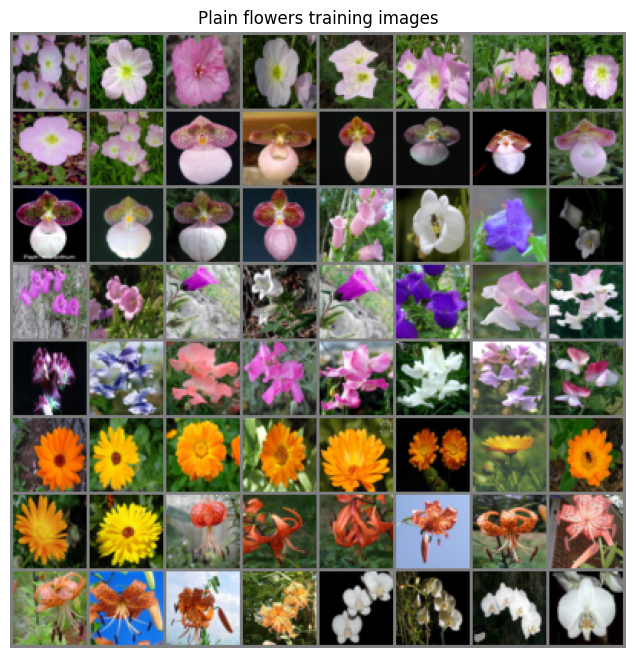

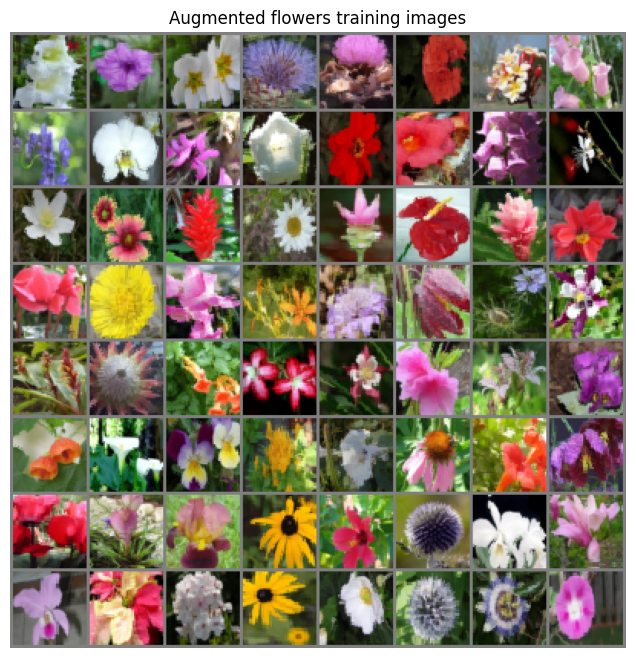

In [ ]:
show_batch_from_loader(trainloader_plain, title="Plain flowers training images")
show_batch_from_loader(trainloader_aug, title="Augmented flowers training images")


In [ ]:
!pip install ninja #need this library to import from github


## Import Score Model Architecture


In [ ]:
from types import SimpleNamespace

score_sde_repository_path = os.path.join(path, "score_sde_pytorch")

if not os.path.exists(score_sde_repository_path):
    !git clone https://github.com/yang-song/score_sde_pytorch.git "{score_sde_repository_path}"

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp

print("imported NCSNpp architecture")


imported NCSNpp architecture


In [ ]:
class NCSNppVPScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales

        def forward(self, images, continuous_timesteps):
            timestep_labels = continuous_timesteps * (self.number_of_scales - 1)

            model_output = self.official_model(images, timestep_labels)

            _, standard_deviation = perturbation_kernel(continuous_timesteps, images)

            score = -model_output / standard_deviation

        return score


In [ ]:
ncsnpp_config = create_ddpmpp_vp_config(image_size=48, image_channels=3)

official_ddpmpp_model = NCSNpp(ncsnpp_config).to(device)


## SDE Objective


In [ ]:
def perturbation_kernel(t, x0):
    integral_beta = bar_b_min * t + 0.5 * (bar_b_max - bar_b_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def vp_loss(x0, net):
    """Continuous VP-SDE denoising score-matching loss."""
    B = x0.shape[0]
    eps=1e-5
    t = torch.rand(B, device=device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_target = -z / std
    score_pred = net(x_t, t)
    loss = (std ** 2 * ((score_pred - score_target) ** 2)).mean()
    return loss


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


In [ ]:
if LOAD_FROM_CHECKPOINT:
    print("Loading checkpoint:", CHECKPOINT_TO_LOAD)

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)


    #DDPMPP network
    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    #DDPMPP network
    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()


    vp_net.load_state_dict(checkpoint["vp_net"])
    ema_net.load_state_dict(checkpoint["ema_net"])

    learning_rate = checkpoint.get("learning_rate", learning_rate)
    weight_decay=checkpoint.get("weight_decay", weight_decay)
    ema_decay=checkpoint.get("ema_decay", ema_decay)
    loss_hist = checkpoint.get("loss_hist", [])
    start_epoch=checkpoint.get("epochs", 0)

    print(start_epoch)

    optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    optimizer.load_state_dict(checkpoint["optimizer"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

                vp_net.train()
                ema_net.eval()

            for p in ema_net.parameters():
                p.requires_grad_(False)

                print("Loaded checkpoint.")
                print("Start epoch:", start_epoch)
                print("Loaded loss history length:", len(loss_hist))

else:
    print("Initializing new model.")

    #DDPM network
    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    #DDPMPP network
    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()


    for p in ema_net.parameters():
        p.requires_grad_(False)

        optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_hist = []
        start_epoch=0

        print("New model initialized.")


Initializing new model.
New model initialized.


## Configuration


In [ ]:
def train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=0, epochs=1760, ema_decay=0.995, checkpoint_every=500, checkpoint_prefix="flower_vp_sde_augmented_ddpmpp"):
    global loss_hist
    end_epoch = start_epoch + epochs

    for epoch in tqdm(range(start_epoch, end_epoch)):
        vp_net.train()
        ema_net.eval()
        epoch_losses = []

        for i, (images, _) in enumerate(trainloader):
            images = images.to(device)
            loss = vp_loss(images, vp_net)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
            optimizer.step()
            update_ema(ema_net, vp_net, decay=ema_decay)

            loss_hist.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

        if SAVE_CHECKPOINTS and checkpoint_every is not None and (epoch + 1) % checkpoint_every == 0:
            checkpoint_path = os.path.join(path, f"{checkpoint_prefix}_{epoch + 1}_epochs.pth")
            checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
            checkpoint["epochs"] = epoch + 1
            checkpoint["batch_size"] = batch_size
            checkpoint["learning_rate"] = learning_rate
            checkpoint["weight_decay"] = weight_decay
            checkpoint["ema_decay"] = ema_decay
            checkpoint["bar_b_min"] = bar_b_min
            checkpoint["bar_b_max"] = bar_b_max
            checkpoint["augmentation"] = True
            checkpoint["target_class_name"] = target_class_name
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    return end_epoch


if RUN_TRAINING:
    print("Training VP-SDE model...")
    final_epoch = train_vp_sde(vp_net, ema_net, optimizer, trainloader_aug, start_epoch=start_epoch, epochs=epochs, ema_decay=ema_decay, checkpoint_every=500, checkpoint_prefix="flower_vp_sde_augmented_ddpmpp")
    final_checkpoint_path = os.path.join(path, f"flower_vp_sde_augmented_final_ddpmpp_{final_epoch}_epochs.pth")
    checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
    checkpoint["epochs"] = final_epoch
    checkpoint["batch_size"] = batch_size
    checkpoint["learning_rate"] = learning_rate
    checkpoint["weight_decay"] = weight_decay
    checkpoint["ema_decay"] = ema_decay
    checkpoint["bar_b_min"] = bar_b_min
    checkpoint["bar_b_max"] = bar_b_max
    checkpoint["augmentation"] = True
    checkpoint["target_class_name"] = target_class_name
    torch.save(checkpoint, final_checkpoint_path)
    print("Saved final checkpoint:", final_checkpoint_path)

else:
    final_epoch = start_epoch


Training VP-SDE model...


  0%|          | 1/1760 [00:04<2:05:10,  4.27s/it]

VP epoch 0 | Mean loss 0.9717


  1%|          | 11/1760 [00:30<1:16:49,  2.64s/it]

VP epoch 10 | Mean loss 0.2911


...

VP epoch 1740 | Mean loss 0.0289


 99%|█████████▉| 1751/1760 [1:14:42<00:22,  2.55s/it]

VP epoch 1750 | Mean loss 0.0327


100%|██████████| 1760/1760 [1:15:05<00:00,  2.56s/it]


Saved final checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_augmented_final_ddpmpp_1760_epochs.pth


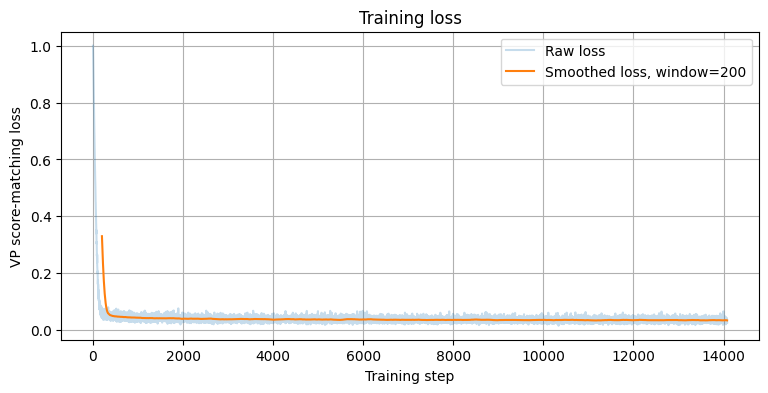

In [ ]:
plot_loss(loss_hist, smooth_window=200)


## Sampling


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_pc_vp_sde_continuous(net, num_samples=64, img_shape=(3, 48, 48), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=0, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


100%|██████████| 999/999 [00:25<00:00, 39.86it/s]


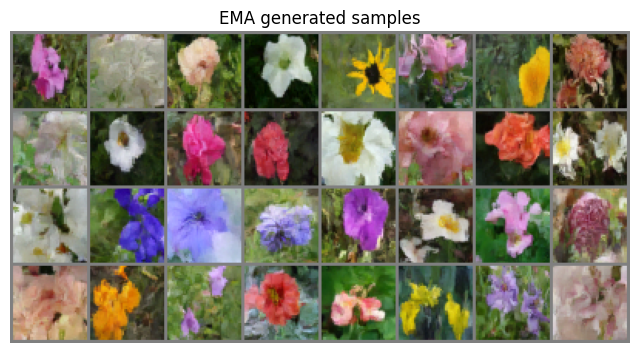

100%|██████████| 999/999 [00:24<00:00, 39.99it/s]


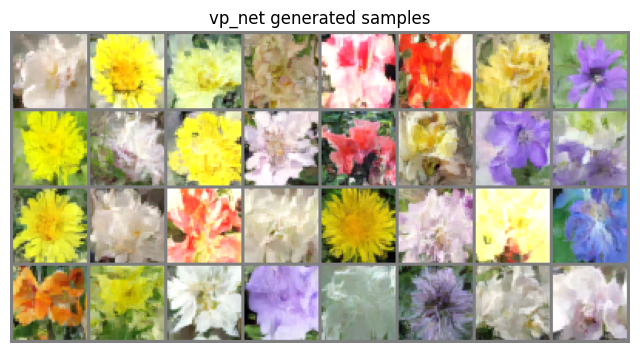

In [ ]:
samples_ema = sample_pc_vp_sde_continuous(ema_net, num_samples=32, img_shape=(3, 48, 48), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_ema, title="EMA generated samples", nrow=8)

samples_raw = sample_pc_vp_sde_continuous(vp_net, num_samples=32, img_shape=(3, 48, 48), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_raw, title="vp_net generated samples", nrow=8)


In [ ]:
save_tensor_images_as_grid(samples_ema, os.path.join(path, 'ema_generated_samples_grid.png'), nrow=8)

save_tensor_images_as_grid(samples_raw, os.path.join(path, 'vp_generated_samples_grid.png'), nrow=8)


Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_generated_samples_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/vp_generated_samples_grid.png


In [ ]:
@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 48, 48), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_pc_vp_sde_continuous(model, num_samples=current_batch, img_shape=img_shape, num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise)
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


## FID Evaluation


In [ ]:
def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_pc_vp_sde_continuous(
            model, num_samples=current_batch, img_shape=(3, 48, 48),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


def fid_sampling_steps_experiment(model, real_loader, steps_list=(100, 250, 500, 1000), num_generated=1000, gen_batch_size=64, corrector_steps=0):
    results = {}

    for steps in steps_list:
        print("\n====================================")
        print("Computing FID with num_steps =", steps)
        print("====================================")
        start_time = time.time()
        fid_value = compute_fid_for_model(model, real_loader, num_generated=num_generated, gen_batch_size=gen_batch_size,
            real_max_images=1000, num_steps=steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True)
        elapsed = time.time() - start_time
        results[steps] = {"fid": fid_value, "time_seconds": elapsed}
        print(f"num_steps={steps} | FID={fid_value:.4f} | time={elapsed:.2f}s")

    return results


## Memorization Check


In [ ]:
@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


'\ndef save_memorization_report(mem_results, filename):\n    os.makedirs(os.path.dirname(filename), exist_ok=True)\n\n    distances = mem_results["nearest_distances"].numpy()\n\n    with open(filename, "w") as f:\n        f.write("Memorization nearest-neighbor report\n")\n        f.write("====================================\n")\n        f.write(f"Number of generated samples: {len(distances)}\n")\n        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")\n        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")\n        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")\n        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")\n        f.write("\n")\n        f.write("Interpretation:\n")\n        f.write(\n            "Very small nearest-neighbor distances may indicate memorization, "\n            "especially if generated images visually match training images. "\n            "Larger distances suggest that generated image

In [ ]:
def compare_raw_vs_ema(vp_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=0):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=vp_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw vp_net samples", nrow=8)
    show_images(samples_ema[:64], title="EMA ema_net samples", nrow=8)
    save_tensor_images_as_grid(samples_raw[:64], os.path.join(path, 'comparison_raw_vp_net_grid.png'), nrow=8)
    save_tensor_images_as_grid(samples_ema[:64], os.path.join(path, 'comparison_ema_net_grid.png'), nrow=8)
    return samples_raw, samples_ema


In [ ]:
def run_full_evaluation(model, model_name="ema_net", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=0):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 48, 48), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)
    save_tensor_images_as_grid(samples[:64], os.path.join(path, f'{model_name}_generated_grid.png'), nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=1000, num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader_plain, num_generated=mem_num_generated, generation_batch_size=64,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=1e-3, snr=0.01,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


100%|██████████| 999/999 [00:23<00:00, 42.37it/s]


Generated 24/24 samples
you are here


100%|██████████| 999/999 [00:23<00:00, 43.14it/s]


Generated 24/24 samples


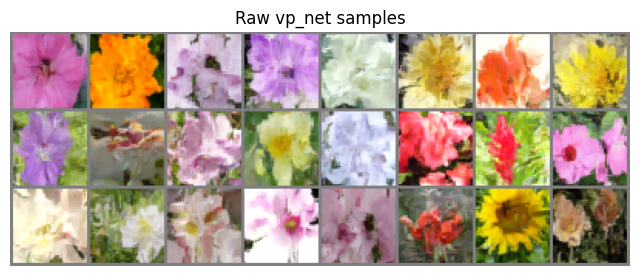

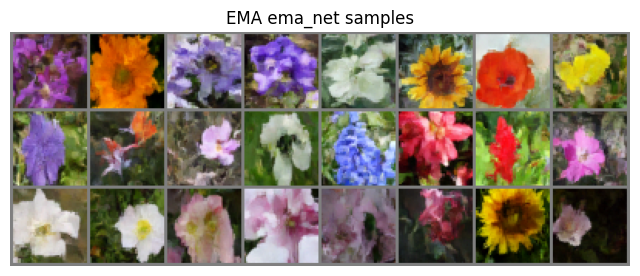

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_raw_vp_net_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/comparison_ema_net_grid.png

Running full evaluation for: vp_net1600_epochs


100%|██████████| 999/999 [00:29<00:00, 33.71it/s]


Generated 64/64 samples


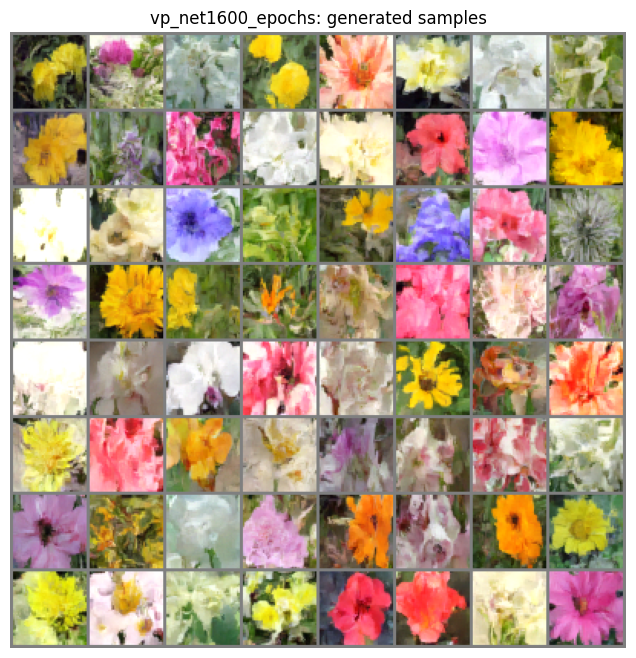

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/vp_net1600_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:29<00:00, 33.57it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:29<00:00, 33.64it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:25<00:00, 39.39it/s]


Generated images added to FID: 1000/1000
FID: 126.25982666015625
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:30<00:00, 33.19it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.21355514228343964
Median nearest-neighbor MSE: 0.20344042778015137
Minimum nearest-neighbor MSE: 0.0859542191028595
Maximum nearest-neighbor MSE: 0.38974398374557495


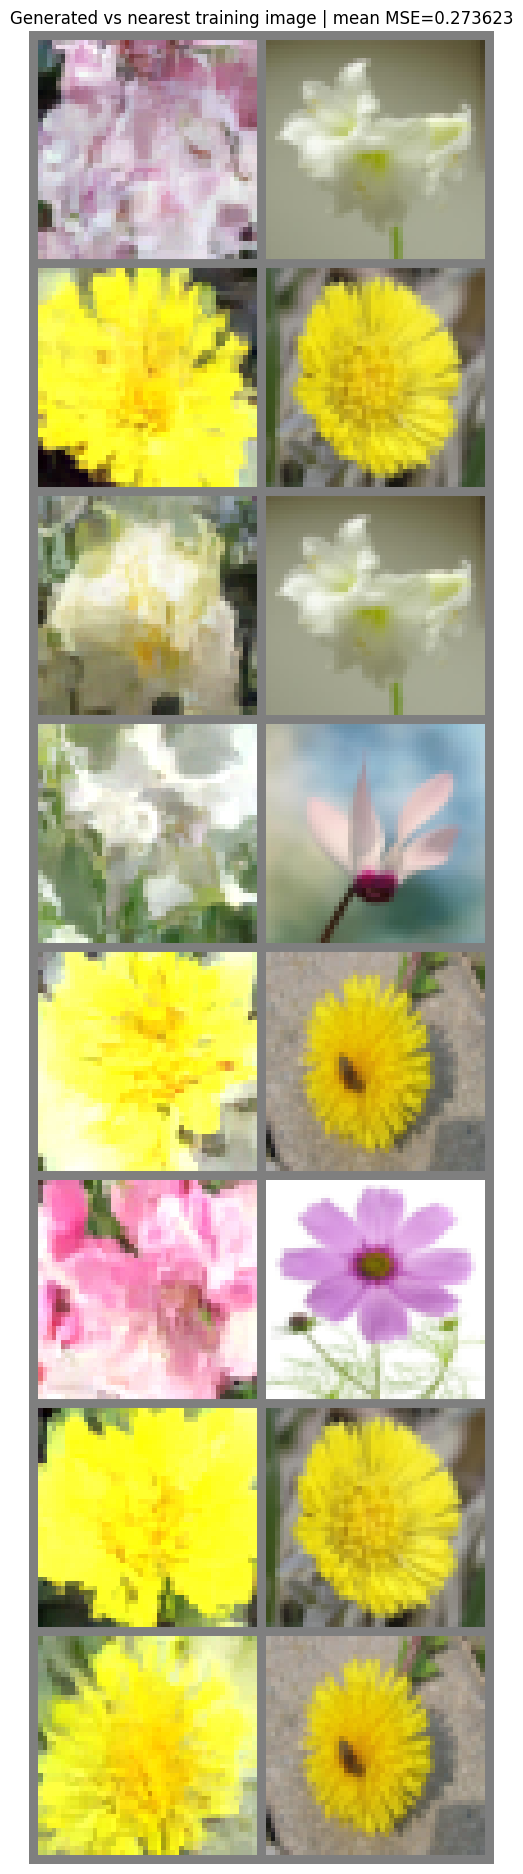

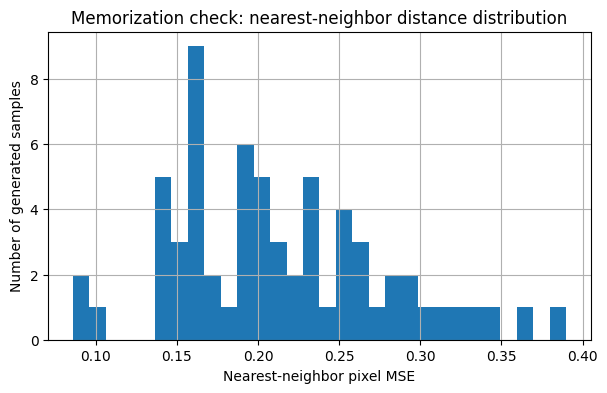

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/vp_net1600_epochs_evaluation_results.txt
{'model_name': 'vp_net1600_epochs', 'fid': 126.25982666015625, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.21355514228343964, 'mem_median_nn_mse': 0.20344042778015137, 'mem_min_nn_mse': 0.0859542191028595, 'mem_max_nn_mse': 0.38974398374557495}
Final VP_net evaluation results:
{'model_name': 'vp_net1600_epochs', 'fid': 126.25982666015625, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.21355514228343964, 'mem_median_nn_mse': 0.20344042778015137, 'mem_min_nn_mse': 0.0859542191028595, 'mem_max_nn_mse': 0.38974398374557495}

Running full evaluation for: EMA_net1600_epochs


100%|██████████| 999/999 [00:29<00:00, 33.37it/s]


Generated 64/64 samples


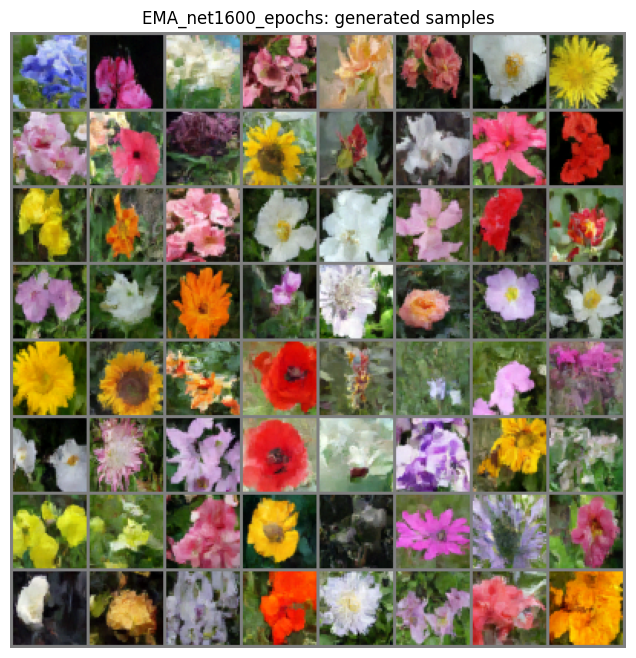

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:30<00:00, 33.22it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:30<00:00, 33.27it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:25<00:00, 39.15it/s]


Generated images added to FID: 1000/1000
FID: 89.56846618652344
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:30<00:00, 32.58it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.18642190098762512
Median nearest-neighbor MSE: 0.185455322265625
Minimum nearest-neighbor MSE: 0.07265514135360718
Maximum nearest-neighbor MSE: 0.40592148900032043


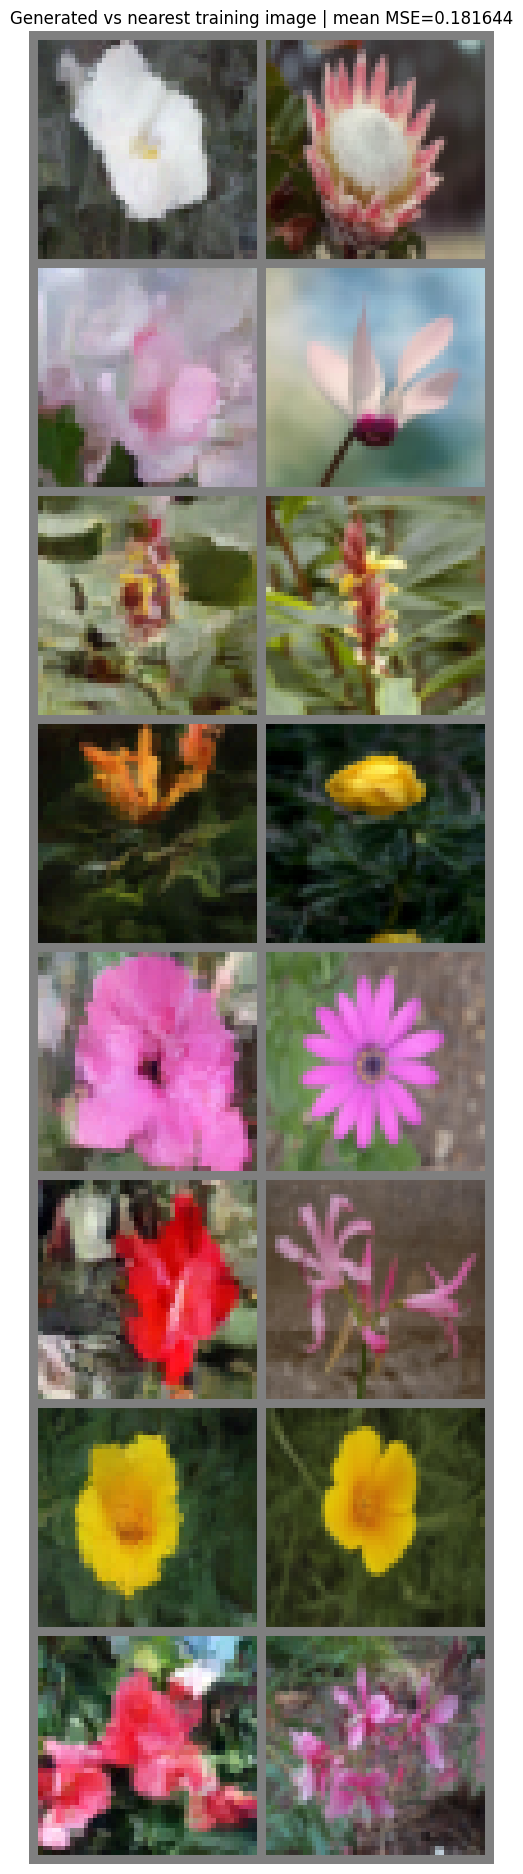

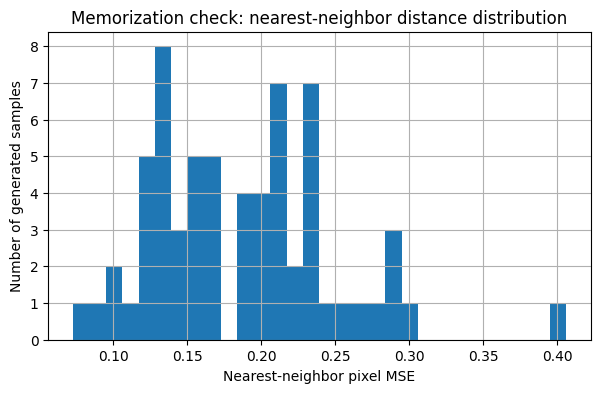

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_evaluation_results.txt
{'model_name': 'EMA_net1600_epochs', 'fid': 89.56846618652344, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.18642190098762512, 'mem_median_nn_mse': 0.185455322265625, 'mem_min_nn_mse': 0.07265514135360718, 'mem_max_nn_mse': 0.40592148900032043}
Final EMA-net evaluation results:
{'model_name': 'EMA_net1600_epochs', 'fid': 89.56846618652344, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.18642190098762512, 'mem_median_nn_mse': 0.185455322265625, 'mem_min_nn_mse': 0.07265514135360718, 'mem_max_nn_mse': 0.40592148900032043}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:
    # Compare raw and EMA models visually
    samples_raw_compare, samples_ema_compare = compare_raw_vs_ema(
    vp_net=vp_net,
    ema_net=ema_net,
    num_samples=24, #24
    num_steps=sample_num_steps,
    corrector_steps=sample_corrector_steps
    )

    # Main full evaluation on VP model
    vp_net_results_ = run_full_evaluation(model=vp_net, model_name=f"vp_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final VP_net evaluation results:")
    print(vp_net_results_)

if RUN_EVALUATION_AFTER_TRAINING:

    # Main full evaluation on EMA model
    vp_net_results_ = run_full_evaluation(model=ema_net, model_name=f"EMA_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(vp_net_results_)



Running full evaluation for: EMA_net1600_epochs


100%|██████████| 999/999 [00:30<00:00, 32.59it/s]


Generated 64/64 samples


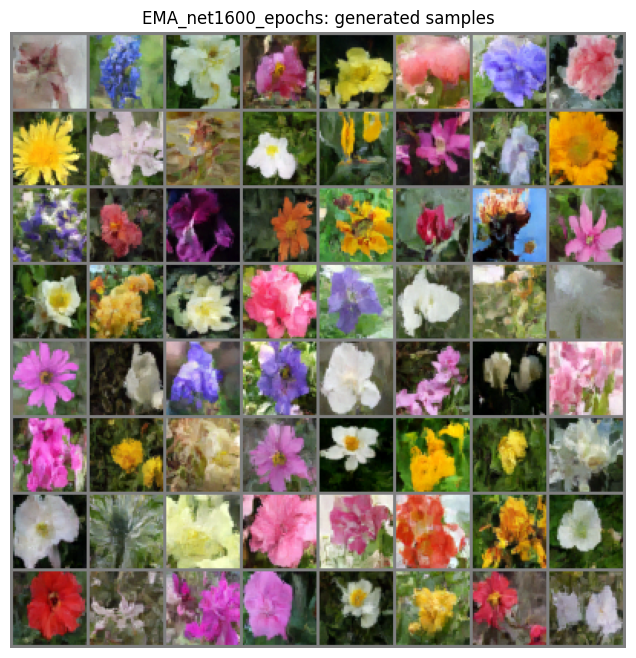

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:30<00:00, 32.77it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:30<00:00, 32.63it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:25<00:00, 39.75it/s]


Generated images added to FID: 1000/1000
FID: 90.90812683105469
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:30<00:00, 33.09it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.17907056212425232
Median nearest-neighbor MSE: 0.1696687936782837
Minimum nearest-neighbor MSE: 0.08611374348402023
Maximum nearest-neighbor MSE: 0.3344566822052002


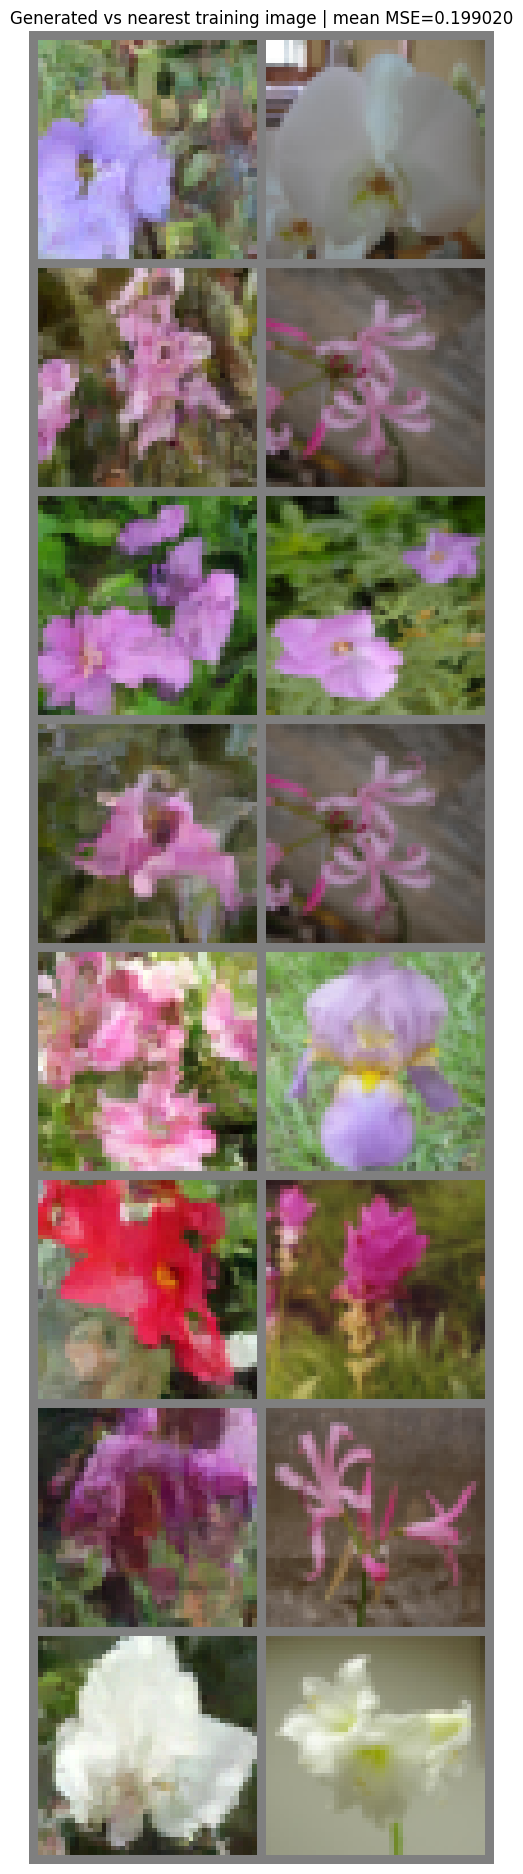

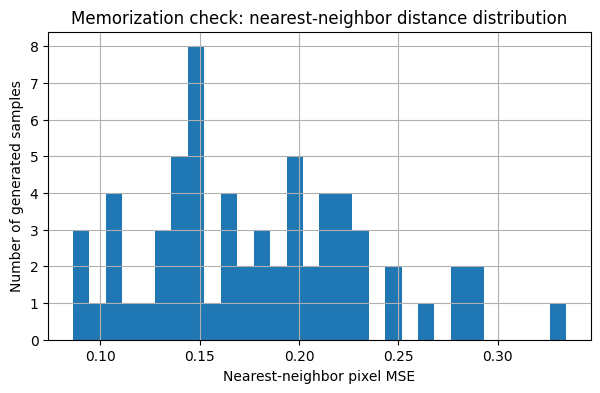

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/EMA_net1600_epochs_evaluation_results.txt
{'model_name': 'EMA_net1600_epochs', 'fid': 90.90812683105469, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.17907056212425232, 'mem_median_nn_mse': 0.1696687936782837, 'mem_min_nn_mse': 0.08611374348402023, 'mem_max_nn_mse': 0.3344566822052002}
Final EMA-net evaluation results:
{'model_name': 'EMA_net1600_epochs', 'fid': 90.90812683105469, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.17907056212425232, 'mem_median_nn_mse': 0.1696687936782837, 'mem_min_nn_mse': 0.08611374348402023, 'mem_max_nn_mse': 0.3344566822052002}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:

    # Main full evaluation on EMA model
    vp_net_results_ = run_full_evaluation(model=ema_net, model_name=f"EMA_net{1600}_epochs",
        fid_num_generated=fid_num_generated, mem_num_generated=mem_num_generated, num_steps=sample_num_steps,
        corrector_steps=sample_corrector_steps)

    print("Final EMA-net evaluation results:")
    print(vp_net_results_)


In [ ]:
eval_checkpoint_path = os.path.join(
    path,
    "/content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_augmented_final_ddpmpp_1760_epochs.pth" #flower_vp_sde_augmented_ddpmpp_1760_epochs
)

eval_epoch = 1760 #1760

# the same settings as before
eval_num_steps = 1000
eval_corrector_steps = 0

# FID/memorization sample counts
# Keep these fixed across augmented and non-augmented models for fair comparison.
eval_fid_num_generated = 1000
eval_mem_num_generated = 64

assert os.path.exists(eval_checkpoint_path), f"Checkpoint not found: {eval_checkpoint_path}"

print("Evaluation checkpoint:", eval_checkpoint_path)
print("FID generated samples:", eval_fid_num_generated)
print("Memorization generated samples:", eval_mem_num_generated)
print("Sampling steps:", eval_num_steps)


Evaluation checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/flower_vp_sde_augmented_final_ddpmpp_1760_epochs.pth
FID generated samples: 1000
Memorization generated samples: 64
Sampling steps: 1000


In [ ]:
checkpoint = torch.load(eval_checkpoint_path, map_location=device)


# #DDPMPP network
vp_net_1760 = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

#DDPMPP network
ema_net_1760 = copy.deepcopy(vp_net_1760).to(device)
ema_net_1760.eval()

vp_net_1760.load_state_dict(checkpoint["vp_net"])
ema_net_1760.load_state_dict(checkpoint["ema_net"])

vp_net_1760.eval()
ema_net_1760.eval()

for p in vp_net_1760.parameters():
    p.requires_grad_(False)

for p in ema_net_1760.parameters():
    p.requires_grad_(False)

# Restore VP-SDE beta schedule from checkpoint if it exists
bar_b_min = checkpoint.get("bar_b_min", bar_b_min)
bar_b_max = checkpoint.get("bar_b_max", bar_b_max)

loaded_epoch = checkpoint.get("epochs", eval_epoch)
loaded_target_class = checkpoint.get("target_class_name", target_class_name)
loaded_augmentation = checkpoint.get("augmentation", "unknown")

print("Loaded checkpoint successfully.")
print("Loaded epoch:", loaded_epoch)
print("Target class:", loaded_target_class)
print("Augmentation:", loaded_augmentation)
print("bar_b_min:", bar_b_min)
print("bar_b_max:", bar_b_max)


Loaded checkpoint successfully.
Loaded epoch: 1760
Target class: flowers
Augmentation: True
bar_b_min: 0.1
bar_b_max: 20.0



Running full evaluation for: raw_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:30<00:00, 32.89it/s]


Generated 64/64 samples


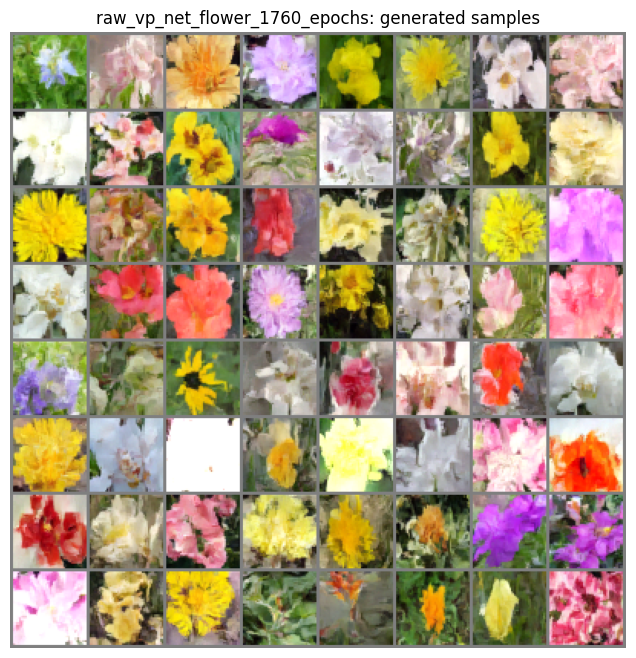

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:30<00:00, 32.92it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:29<00:00, 33.46it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:25<00:00, 38.61it/s]


Generated images added to FID: 1000/1000
FID: 129.89566040039062
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:30<00:00, 32.84it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.21076565980911255
Median nearest-neighbor MSE: 0.20972423255443573
Minimum nearest-neighbor MSE: 0.07382678985595703
Maximum nearest-neighbor MSE: 0.37562745809555054


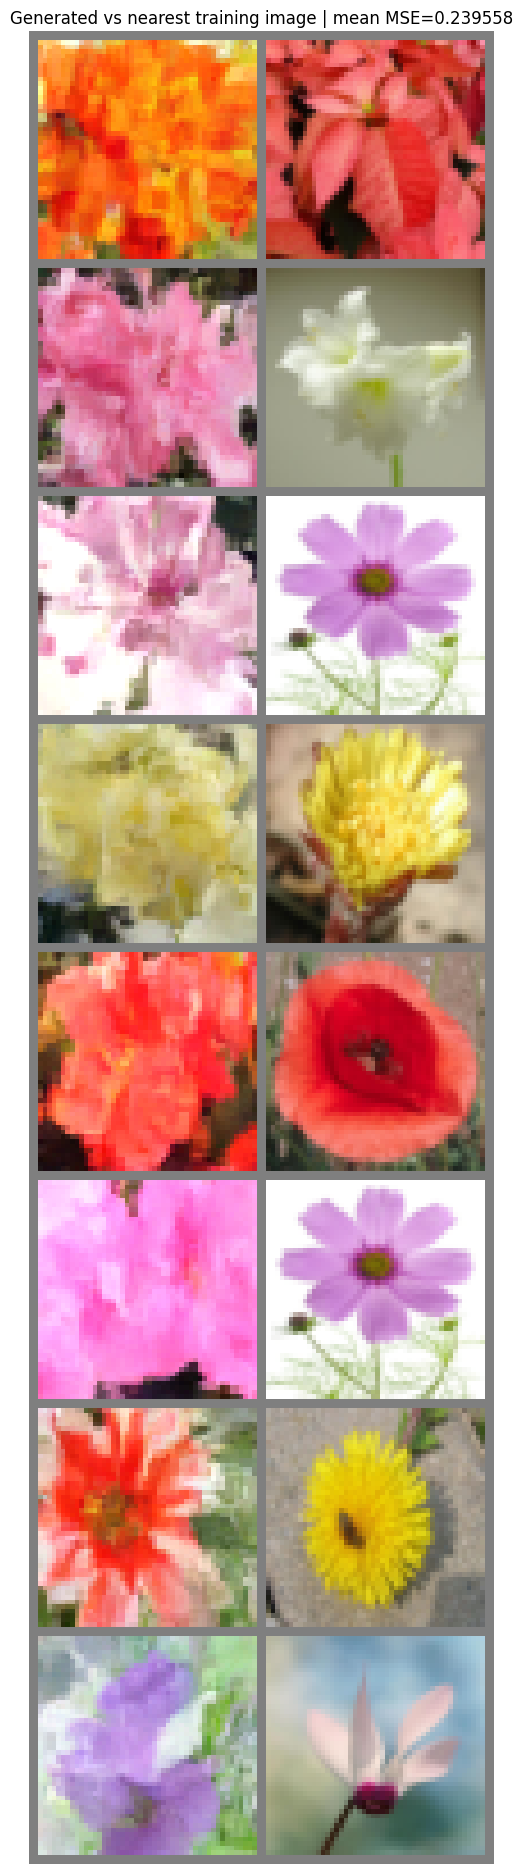

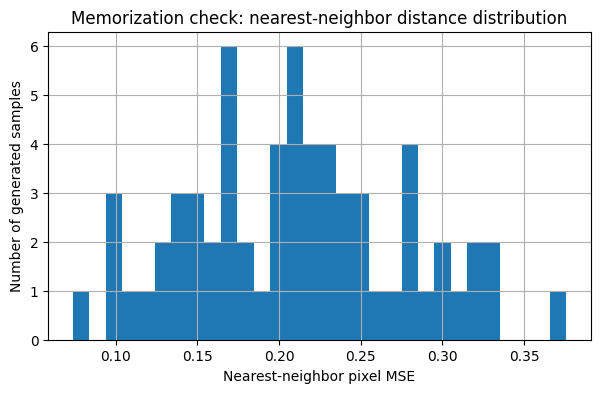

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 129.89566040039062, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.21076565980911255, 'mem_median_nn_mse': 0.20972423255443573, 'mem_min_nn_mse': 0.07382678985595703, 'mem_max_nn_mse': 0.37562745809555054}
Raw VP-net evaluation results:
{'model_name': 'raw_vp_net_flower_1760_epochs', 'fid': 129.89566040039062, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.21076565980911255, 'mem_median_nn_mse': 0.20972423255443573, 'mem_min_nn_mse': 0.07382678985595703, 'mem_max_nn_mse': 0.37562745809555054}


In [ ]:
raw_vp_1760_results = run_full_evaluation(model=vp_net_1760, model_name=f"raw_vp_net_flower_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("Raw VP-net evaluation results:")
print(raw_vp_1760_results)



Running full evaluation for: ema_vp_net_flower_1760_epochs


100%|██████████| 999/999 [00:30<00:00, 33.26it/s]


Generated 64/64 samples


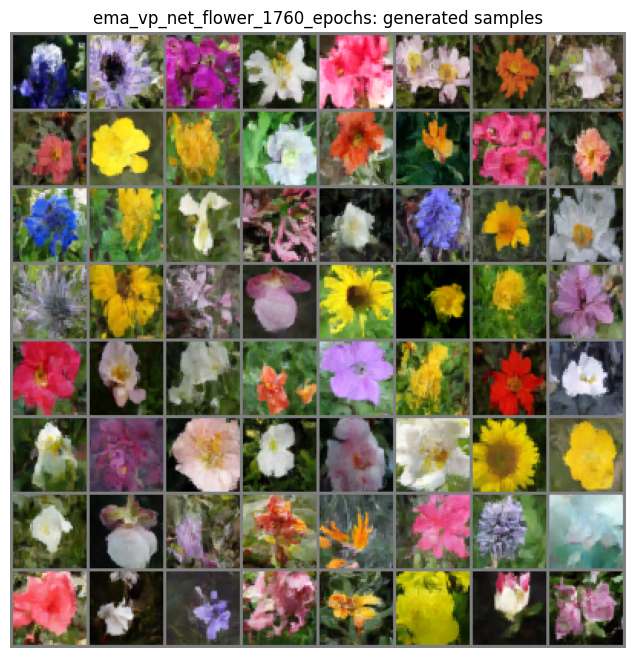

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_generated_grid.png
Real images added to FID: 1024


100%|██████████| 999/999 [00:30<00:00, 33.24it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:29<00:00, 33.37it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:25<00:00, 39.75it/s]


Generated images added to FID: 1000/1000
FID: 89.25296783447266
Reference images: torch.Size([1020, 3, 48, 48])
Generating images for memorization check...


100%|██████████| 999/999 [00:29<00:00, 33.78it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 48, 48])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.17531172931194305
Median nearest-neighbor MSE: 0.16800785064697266
Minimum nearest-neighbor MSE: 0.08069977909326553
Maximum nearest-neighbor MSE: 0.3324032425880432


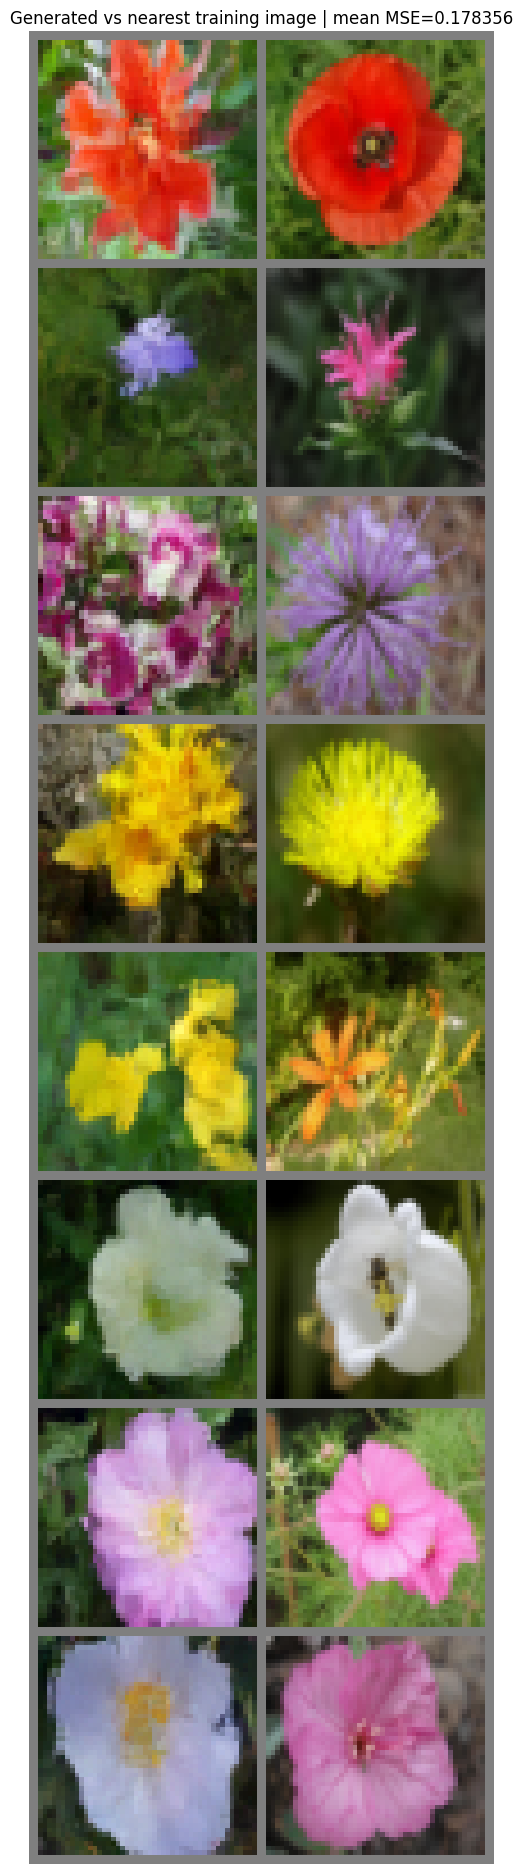

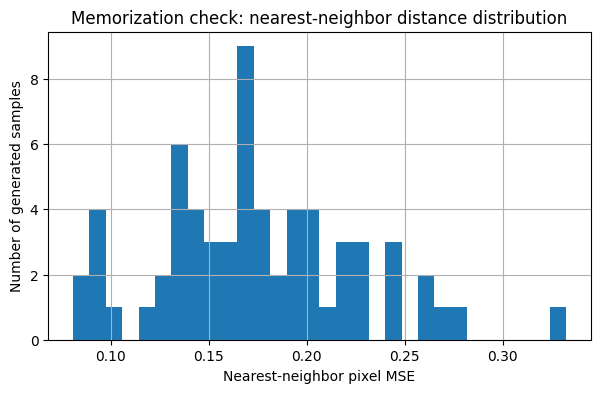

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_flower_1760_epochs_evaluation_results.txt
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 89.25296783447266, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.17531172931194305, 'mem_median_nn_mse': 0.16800785064697266, 'mem_min_nn_mse': 0.08069977909326553, 'mem_max_nn_mse': 0.3324032425880432}
EMA VP-net evaluation results:
{'model_name': 'ema_vp_net_flower_1760_epochs', 'fid': 89.25296783447266, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.17531172931194305, 'mem_median_nn_mse': 0.16800785064697266, 'mem_min_nn_mse': 0.08069977909326553, 'mem_max_nn_mse': 0.3324032425880432}


In [ ]:
ema_vp_1760_results = run_full_evaluation(model=ema_net_1760, model_name=f"ema_vp_net_flower_{eval_epoch}_epochs",
    fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps,
    corrector_steps=eval_corrector_steps)

print("EMA VP-net evaluation results:")
print(ema_vp_1760_results)
